In [22]:
# imports
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from src.data.dataset import TransformedDataset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, HuberRegressor
from sklearn.dummy import DummyRegressor
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.metrics import r2_score, get_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats.mstats import winsorize, spearmanr
from itertools import product
from joblib import Parallel, delayed
from numba import njit
from xgboost import XGBRegressor
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import torch.optim as optim
from ast import literal_eval
import warnings

warnings.filterwarnings(
    "ignore",
    message="Got `batch_size` less than 1 or larger than sample size.*",
    category=UserWarning,
    module="sklearn.neural_network._multilayer_perceptron"
)

np.random.seed(42)
torch.manual_seed(42)

In [2]:
# play around to create rolling window backtest, ensuring no data leakage

dl = DataLoad()
dfs = dl.load_multiple_data("features")

MS.csv loaded succesfully
MMM.csv loaded succesfully
GS.csv loaded succesfully
CAT.csv loaded succesfully
AVGO.csv loaded succesfully
BA.csv loaded succesfully
MCD.csv loaded succesfully
HD.csv loaded succesfully
UNH.csv loaded succesfully
AMZN.csv loaded succesfully
META.csv loaded succesfully
AAPL.csv loaded succesfully
SLB.csv loaded succesfully
JPM.csv loaded succesfully
VZ.csv loaded succesfully
GOOG.csv loaded succesfully
CVX.csv loaded succesfully
NEE.csv loaded succesfully
BAC.csv loaded succesfully
UPS.csv loaded succesfully
MSFT.csv loaded succesfully
LIN.csv loaded succesfully
CMCSA.csv loaded succesfully
XOM.csv loaded succesfully
NKE.csv loaded succesfully
NVDA.csv loaded succesfully
JNJ.csv loaded succesfully
ABBV.csv loaded succesfully
PFE.csv loaded succesfully
DOW.csv loaded succesfully


In [3]:
# to start, create initial train set, first 3 years of data, minus the warm up period removed
df = dfs["AAPL"]
df.index[0]

Timestamp('2010-07-30 00:00:00')

In [4]:
df.index[df.index.year == 2012].max()

Timestamp('2012-12-31 00:00:00')

In [5]:
# create initial training period
df_train = df.loc[:'2012-12-31']

X = df_train.drop(columns="Target")
y = df_train["Target"]

In [6]:
# standardize (mean 0 and std 1) and winsorize (clip 1% and 99% outliers)

X = np.column_stack([winsorize(X[col].values, limits=[0.01, 0.01]) for col in X.columns])

scaler = StandardScaler()
X = scaler.fit_transform(X)



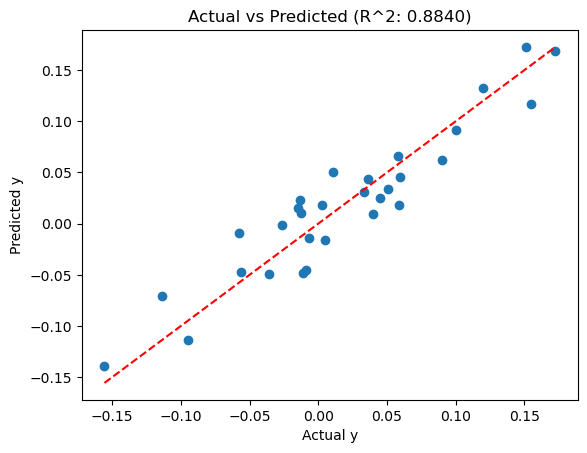

In [7]:
# train simple linear regression for now
# throughout this notebook models will be evaluated on same data used to train
# not accurate representation of performance, very biased
# will not use test results now as this is simply experimentation and trials
# and if test performance is seen now, can be used later to tune again and will lead to data leakage

model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

In [8]:
# very easy to predict as AAPL stock has only gone up

# join dataset, all 30 stocks at the same time now, but must wins + scale individually
# otherwise scale differences between stocks will crush data

df_list = []
for dataframe in dfs.values():
    df_train = dataframe.loc[:'2012-12-31']
    if df_train.empty: # for stocks not in universe yet
        continue
    train_x_wins = np.column_stack([winsorize(df_train[col].values, limits=[0.01, 0.01]) for col in df_train.drop(columns="Target").columns])
    scaler = StandardScaler()
    train_x_scaled = scaler.fit_transform(train_x_wins)
    df_train_scaled = pd.DataFrame(train_x_scaled, columns=df_train.drop(columns="Target").columns, index=df_train.index)
    df_train_scaled["Target"] = df_train["Target"]
    df_list.append(df_train_scaled)

df = pd.concat(df_list, axis=0).reset_index(drop=True)
df.shape

(812, 22)

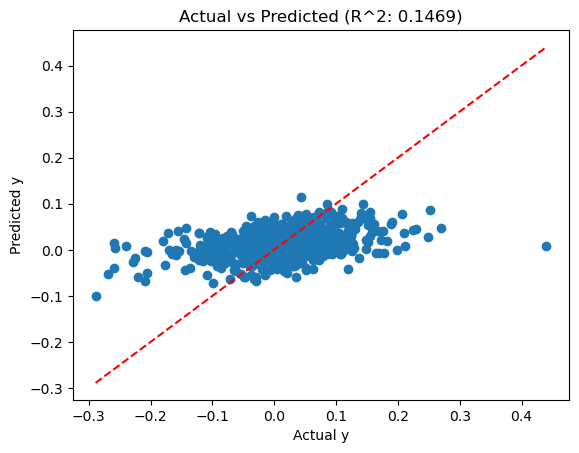

In [9]:
X = df.drop(columns="Target")
y = df["Target"]

model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

In [10]:
# for a multitude of stocks, lin reg doesnt do so well

# create hyper parameter search, must create custom scaler + custom pipe + custom grid search
# sklearn default pipes and timeseries splits and grid search doesnt work with how my current dataset is created
# we dont have a "test" data so to speak, the prediction we test on (log returns of the next month) are part of the row of data we use to predict
# our predictions are defased by 1 month
# expanding-window, one-step-ahead forecasting where the prediction is made on the latest available row (not the next row)
# sklearn packages would treat this last row as "test" data, which wouldnt be correct 

# we will try with L1 lasso regression
# must create own personal transformer, normal packages dont allow me to transform each stock individually (wins + scale)

@njit
def winsorize_and_standardize(data, lower, upper):
    n, m = data.shape
    out = np.empty_like(data)

    for j in range(m):
        col = data[:, j].copy()
        sorted_col = np.sort(col)

        low_val = sorted_col[int(n * lower)]
        high_val = sorted_col[int(n * (1 - upper)) - 1]

        for i in range(n):
            if col[i] < low_val:
                col[i] = low_val
            elif col[i] > high_val:
                col[i] = high_val

        mean = col.mean()
        std = col.std()
        if std == 0:
            std = 1e-8

        for i in range(n):
            out[i, j] = (col[i] - mean) / std

    return out

class PerStockTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, stock_col='Ticker', winsor_limits=(0.01, 0.01)):
        self.stock_col = stock_col
        self.winsor_limits = winsor_limits

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.reset_index(drop=True)

        features = [c for c in X.columns if c != self.stock_col]
        X_arr = X[features].to_numpy(dtype=np.float64)
        transformed = np.empty_like(X_arr, dtype=np.float64)

        lower, upper = self.winsor_limits

        groups = X.groupby(self.stock_col).groups

        for _, idx in groups.items():
            idx = np.array(list(idx))
            data = X_arr[idx, :]

            transformed[idx, :] = winsorize_and_standardize(
                data, lower, upper
            )

        return transformed


In [11]:
# create own personal grid search for specific use case

class RollingGridSearch:
    """
    Rolling-window grid search for time-series / expanding window prediction.
    """

    def __init__(self, model, param_grid, transformer, scoring, min_train_size=24, n_jobs=-1, verbose=1):

        self.model = model
        self.param_grid = param_grid
        self.transformer = transformer
        self.scorer_ = get_scorer(scoring)
        self.min_train_size = min_train_size
        self.n_jobs = n_jobs
        self.verbose = verbose

    def _param_combinations(self):
        keys, values = list(self.param_grid.keys()), list(self.param_grid.values())
        for combo in product(*values):
            yield dict(zip(keys, combo))

    def _evaluate_params(self, params, Xs, y_values):
        scores = []
        model = clone(self.model)
        model.set_params(**params)

        for i, X_scaled in enumerate(Xs):
            t = self.min_train_size + i

            model.fit(X_scaled[:t], y_values[:t])
            score = self.scorer_(model, X_scaled[t:t+1], y_values[t:t+1])
            scores.append(score)

        return {"params": params, "score": np.mean(scores)}

    def fit(self, X, y):
        param_list = list(self._param_combinations())
        y_values = y.values

        if self.verbose:
            print("Precomputing rolling transformations...")

        X_trans = [
            clone(self.transformer).fit_transform(
                X.iloc[:t+1].reset_index(drop=True)
            )
            for t in range(self.min_train_size, len(X))
        ]

        if self.verbose:
            print("Running grid search...")

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._evaluate_params)(params, X_trans, y_values)
            for params in param_list
        )

        self.results_ = results
        best = max(results, key=lambda x: x["score"])
        self.best_params_ = best["params"]
        self.best_score_ = best["score"]

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_transformer_ = clone(self.transformer)
        X_scaled_full = self.best_transformer_.fit_transform(X)

        self.best_model_ = clone(self.model)
        self.best_model_.set_params(**self.best_params_)
        self.best_model_.fit(X_scaled_full, y_values)

        return self

    def predict(self, X):
        X_scaled = self.best_transformer_.transform(X)
        return self.best_model_.predict(X_scaled)       

In [12]:
# add ticker to each df so the transformer knows who is who
for ticker, df_stock in dfs.items():
    df_stock['Ticker'] = ticker

# combine and sort by date
df_all = pd.concat(dfs.values()).sort_index()

df_train = df_all.loc[:'2012-12-31']
X = df_train.drop(columns=['Target'])
y = df_train['Target']

Best Alpha: {'alpha': np.float64(0.001)}
Best Score: -0.011652259781257857
8 de 18
Index(['Log Returns', 'Monthly Log Returns', 'Semi-annual Log Returns',
       'Volatility Ratio', 'MA20/MA60', 'Percentage Intraday Range',
       'Monthly Kurtosis', 'Quarterly Efficiency Ratio'],
      dtype='str')
                               feature  coefficient  non_zero
0                               Volume    -0.000000     False
1                          Log Returns    -0.001423      True
2                  Monthly Log Returns     0.001525      True
3                Quarterly Log Returns     0.000000     False
4              Semi-annual Log Returns     0.001805      True
5               Semi-annual Volatility    -0.000000     False
6                     Volatility Ratio    -0.000344      True
7                            MA20/MA60     0.000503      True
8            Percentage Intraday Range    -0.000188      True
9                                  RSI    -0.000000     False
10             10

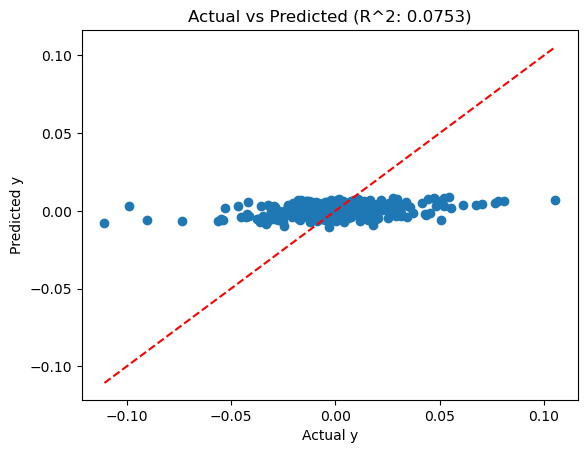

In [13]:
# dont need to use sklearn pipe, sklearn timeseries split or sklearn grid search
# custom built grid search handles data transformation and hpt tuning automatically with correct procedure
# for what data to use at what time point, which data gets transformed, whats predicted

param_grid = {'alpha': np.logspace(-1, -5, 5)}
grid = RollingGridSearch(Lasso(max_iter=10000, tol=1e-4, selection="random"), param_grid, PerStockTransformer(stock_col='Ticker'),'neg_root_mean_squared_error', 1,verbose=0)

grid.fit(X, y)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

Best Alpha: {'alpha': np.float64(0.1)}
Best Score: -0.012163806712587943


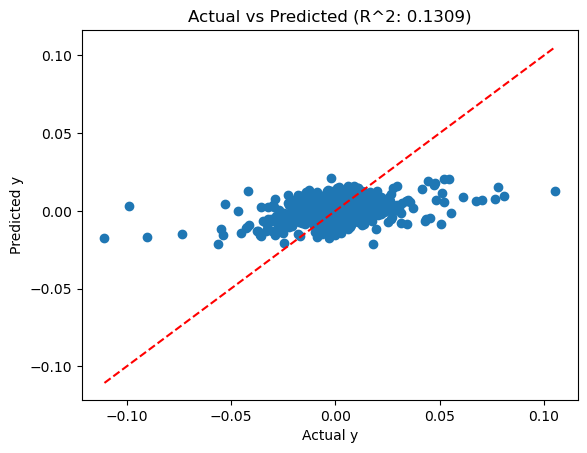

In [14]:
# try ridge regression now

param_grid = {'alpha': np.logspace(-1, -5, 5)}
grid = RollingGridSearch(Ridge(max_iter=10000,solver="cholesky"), param_grid, PerStockTransformer(stock_col='Ticker'),'neg_root_mean_squared_error', 1,verbose=0)

grid.fit(X, y)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

Best Alpha: {'alpha': np.float64(0.01), 'l1_ratio': 0.1}
Best Score: -0.011650250920025048
8 de 18
Index(['Log Returns', 'Monthly Log Returns', 'Semi-annual Log Returns',
       'Volatility Ratio', 'MA20/MA60', 'Percentage Intraday Range',
       'Monthly Kurtosis', 'Quarterly Efficiency Ratio'],
      dtype='str')
                               feature  coefficient  non_zero
0                               Volume    -0.000000     False
1                          Log Returns    -0.001401      True
2                  Monthly Log Returns     0.001507      True
3                Quarterly Log Returns     0.000000     False
4              Semi-annual Log Returns     0.001778      True
5               Semi-annual Volatility    -0.000000     False
6                     Volatility Ratio    -0.000341      True
7                            MA20/MA60     0.000512      True
8            Percentage Intraday Range    -0.000191      True
9                                  RSI    -0.000000     False
1

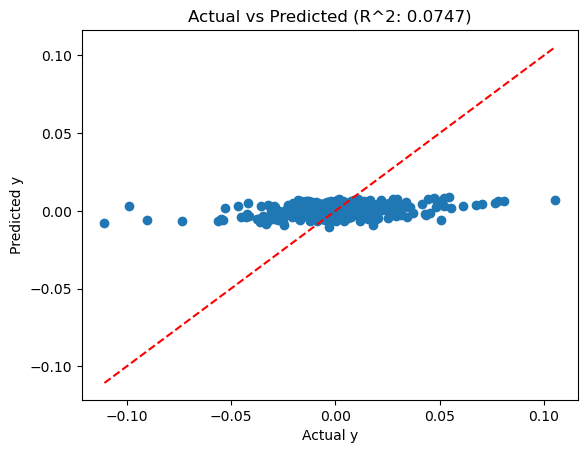

In [15]:
# try elasticnet regression now

param_grid = {'alpha': np.logspace(-1, -5, 5),
              'l1_ratio': [0.1,0.5,0.7,0.9]}
grid = RollingGridSearch(ElasticNet(max_iter=100000), param_grid, PerStockTransformer(stock_col='Ticker'),'neg_root_mean_squared_error', 1,verbose=0)

grid.fit(X, y)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = grid.predict(X)

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

In [ ]:
# now well do an example for the tree models that will be used
# try randomforest

param_grid = {
    'max_depth': [5, 10, 20, 30],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [5, 10, 20]
}


grid = RollingGridSearch(RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=42), param_grid, PerStockTransformer(stock_col='Ticker'),'neg_root_mean_squared_error', 1,verbose=0)

grid.fit(X, y)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

KeyboardInterrupt: 

In [16]:
# tried randomforest with current grid search, computationally very costly, ran for 4 hours with no results
# will attempt to implement an optimized hyper parameter search that doesn't try every combination
# implement optimized hyper parameter search with optuna

class RollingOptunaSearch():

    def __init__(self, model_builder, transformer, scoring, min_train_size=24, n_trials=30, sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.transformer = transformer
        self.scorer_ = get_scorer(scoring)
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.verbose = verbose


        self.sampler = sampler or optuna.samplers.TPESampler()
        self.pruner = pruner or optuna.pruners.SuccessiveHalvingPruner()

    def _build_objective(self, X, y):

        y_values = y.values

        if self.verbose:
            print("Precomputing rolling transformations...")

        X_trans = [
            clone(self.transformer).fit_transform(
                X.iloc[:t+1].reset_index(drop=True)
            )
            for t in range(self.min_train_size, len(X))
        ]

        def objective(trial):

            model = self.model_builder(trial)

            scores = []

            for i, Xs in enumerate(X_trans):
                t = self.min_train_size + i

                model_step = clone(model) if hasattr(model, "get_params") else self.model_builder(trial)
                model_step.fit(Xs[:t], y_values[:t])
                score = self.scorer_(model_step, Xs[t:t+1], y_values[t:t+1])

                scores.append(score)

                trial.report(np.mean(scores), step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            return np.mean(scores)

        return objective

    def fit(self, X, y):

        y_values = y.values


        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        study.optimize(self._build_objective(X, y), n_trials=self.n_trials,n_jobs=-1)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_transformer_ = clone(self.transformer)
        X_scaled = self.best_transformer_.fit_transform(X)

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_))
        self.best_model_.fit(X_scaled, y_values)

        return self

    def predict(self, X):
        X_scaled = self.best_transformer_.transform(X)
        return self.best_model_.predict(X_scaled)

[I 2026-04-02 09:59:25,481] A new study created in memory with name: no-name-f98036d5-a3ff-43c9-bdbe-63b15e92788a


Precomputing rolling transformations...


[I 2026-04-02 10:24:26,344] Trial 4 finished with value: -0.011518183900428308 and parameters: {'n_estimators': 104, 'max_depth': 16, 'max_features': 0.4501497502885321, 'min_samples_leaf': 18, 'min_samples_split': 8}. Best is trial 4 with value: -0.011518183900428308.
[I 2026-04-02 10:24:26,572] Trial 13 pruned. 
[I 2026-04-02 10:24:26,823] Trial 2 pruned. 
[I 2026-04-02 10:24:26,951] Trial 17 pruned. 
[I 2026-04-02 10:24:27,428] Trial 19 pruned. 
[I 2026-04-02 10:24:27,452] Trial 7 pruned. 
[I 2026-04-02 10:24:27,808] Trial 16 pruned. 
[I 2026-04-02 10:24:28,264] Trial 14 pruned. 
[I 2026-04-02 10:24:28,343] Trial 12 pruned. 
[I 2026-04-02 10:24:28,705] Trial 5 pruned. 
[I 2026-04-02 10:24:28,979] Trial 18 pruned. 
[I 2026-04-02 10:24:30,259] Trial 15 pruned. 
[I 2026-04-02 10:24:30,605] Trial 10 pruned. 
[I 2026-04-02 10:24:30,889] Trial 9 pruned. 
[I 2026-04-02 10:24:31,373] Trial 0 pruned. 
[I 2026-04-02 10:24:33,949] Trial 8 pruned. 
[I 2026-04-02 10:24:34,130] Trial 3 pruned. 
[

Best params: {'n_estimators': 281, 'max_depth': 6, 'max_features': 0.795452405254844, 'min_samples_leaf': 3, 'min_samples_split': 14}
Best score: -0.0112328876222271
Best Params: {'n_estimators': 281, 'max_depth': 6, 'max_features': 0.795452405254844, 'min_samples_leaf': 3, 'min_samples_split': 14}
Best Score: -0.0112328876222271
18 de 18
Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Semi-annual Volatility', 'Volatility Ratio',
       'MA20/MA60', 'Percentage Intraday Range', 'RSI',
       '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Monthly Rogers-Satchell Volatility', 'Volatility of Volatility',
       'Monthly Skewness', 'Monthly Kurtosis', 'Quarterly Efficiency Ratio',
       'Monthly Intraday Intensity'],
      dtype='object')
                               feature  importance  non_zero
1                          Log Returns    0.217179      True
13            Volatility of Volatility    0.12437

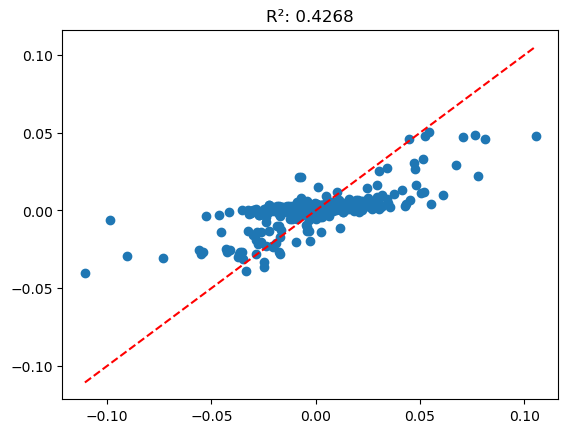

In [ ]:
def rf_builder(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(rf_builder, PerStockTransformer(stock_col="Ticker"), scoring='neg_root_mean_squared_error',min_train_size=1, n_trials=50,verbose=0)

grid.fit(X, y)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

[I 2026-04-02 15:27:28,424] A new study created in memory with name: no-name-bae7681a-3d02-4075-8d87-267d0a5b5c07


[I 2026-04-02 15:32:02,265] Trial 10 finished with value: -0.0119283927798775 and parameters: {'n_estimators': 117, 'learning_rate': 0.0990032305014602, 'max_depth': 8, 'min_child_weight': 7.506128372416106, 'reg_alpha': 0.0003090498498189586, 'reg_lambda': 2.2979123497431275, 'gamma': 0.07553572081556927, 'subsample': 0.5735657036674349, 'colsample_bytree': 0.8700687206654825}. Best is trial 10 with value: -0.0119283927798775.
[I 2026-04-02 15:32:02,337] Trial 15 pruned. 
[I 2026-04-02 15:32:02,404] Trial 8 pruned. 
[I 2026-04-02 15:32:02,639] Trial 4 pruned. 
[I 2026-04-02 15:32:02,604] Trial 16 pruned. 
[I 2026-04-02 15:32:02,443] Trial 3 pruned. 
[I 2026-04-02 15:32:02,660] Trial 18 pruned. 
[I 2026-04-02 15:32:02,907] Trial 19 pruned. 
[I 2026-04-02 15:32:02,808] Trial 14 pruned. 
[I 2026-04-02 15:32:03,011] Trial 5 pruned. 
[I 2026-04-02 15:32:03,172] Trial 6 pruned. 
[I 2026-04-02 15:32:03,182] Trial 1 pruned. 
[I 2026-04-02 15:32:03,323] Trial 17 pruned. 
[I 2026-04-02 15:32:03

Best Params: {'n_estimators': 575, 'learning_rate': 0.01231780915345437, 'max_depth': 5, 'min_child_weight': 12.25510069963494, 'reg_alpha': 0.031378512018715186, 'reg_lambda': 0.5316568856492152, 'gamma': 0.0002576825644226363, 'subsample': 0.9526409601874459, 'colsample_bytree': 0.6706491881239898}
Best Score: -0.010937433386630209
18 de 18
Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Semi-annual Volatility', 'Volatility Ratio',
       'MA20/MA60', 'Percentage Intraday Range', 'RSI',
       '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Monthly Rogers-Satchell Volatility', 'Volatility of Volatility',
       'Monthly Skewness', 'Monthly Kurtosis', 'Quarterly Efficiency Ratio',
       'Monthly Intraday Intensity'],
      dtype='object')
                               feature  importance  non_zero
13            Volatility of Volatility    0.117736      True
7                            MA20/MA60    0.1

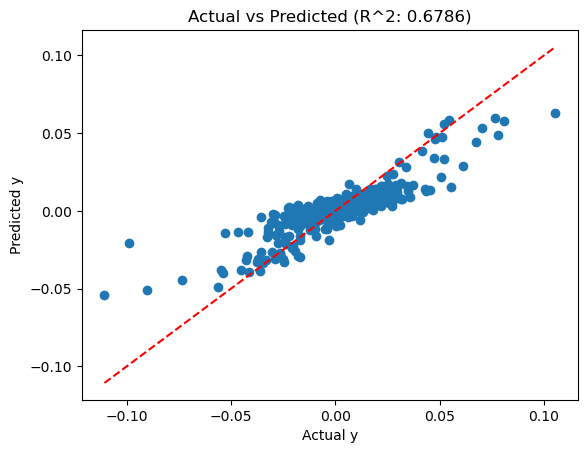

In [24]:
# try xgboost

def xg_builder(trial):
    return XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 750),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight = trial.suggest_float("min_child_weight", 1, 20, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        gamma = trial.suggest_float("gamma", 1e-4, 5.0, log=True),
        subsample=trial.suggest_float("subsample", 0.5,1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        n_jobs=1,
        random_state=42)

grid = RollingOptunaSearch(xg_builder, PerStockTransformer(stock_col="Ticker"), scoring='neg_root_mean_squared_error',min_train_size=1, n_trials=50, verbose=0)

grid.fit(X, y)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

[I 2026-04-02 12:01:04,605] A new study created in memory with name: no-name-10c42023-c3d2-4adf-ba63-6d4222d75b1a
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be cli

Best Params: {'hidden_layer_sizes': (64, 32), 'alpha': 0.005713648327237383, 'learning_rate_init': 0.006657305776729877, 'learning_rate': 'adaptive', 'batch_size': 32, 'activation': 'relu'}
Best Score: -0.02475879164223645


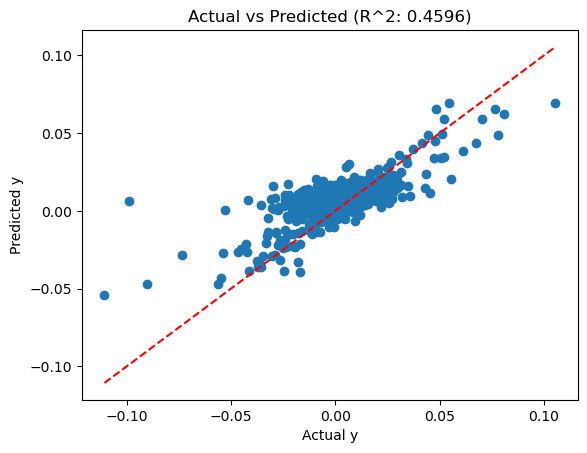

In [ ]:
# test a simple multi layer perceptron

def mlp_builder(trial):
    return MLPRegressor(
        hidden_layer_sizes = trial.suggest_categorical("hidden_layer_sizes",[(50,), (100,), (64, 32), (128,), (128, 64)]),
        alpha=trial.suggest_float("alpha", 1e-4, 1e-2, log=True),
        learning_rate_init=trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        learning_rate=trial.suggest_categorical("learning_rate", ['constant', 'adaptive']),
        batch_size = trial.suggest_categorical("batch_size", [32,64,128]),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        solver='adam',
        max_iter=2000,
        early_stopping=False,
        random_state=42)

grid = RollingOptunaSearch(mlp_builder, PerStockTransformer(stock_col="Ticker"), scoring='neg_root_mean_squared_error',min_train_size=1, n_trials=50, verbose=0)

grid.fit(X, y)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
r2 = r2_score(y, y_pred)
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})")
plt.show()

In [17]:
# even though its not the most data science or ml correct thing (but it kind of works in my context)
# since transformations of past are the same each time, instead of recomputing them all the time, save them as a file and load them in when needed
# that way my transformations are kept exactly the same, which they need to be, but we save on recomputing them everytime
# it works in real time too, because i am taking data on the last day of the month and using it to predict where the stock will be at the end of next month
# so technically once market closes on say 31 jan, i have until market opens on 1 of feb to recompute scaling and transforms
# retrain model and make predictions so that when market opens, positions are ready

# so will make a class im src/data called transform_features that does this job and saves to a new directory in data/
# then will rerun below previous cells to simply load in processed features instead of computing them over and over again
# will improve speed and efficiency

In [13]:
# also quick note, all previous models and graphs and predictions are wrong, target was calculated incorrectly beforet this cell
# targets were not monthly log returns, so models and predictions are off
# from this cell forward dataset has been fixed and new models trained correctly

In [13]:
# first of all will implement own scoring, not for training but for model evaluation
# as we will be creating weighted portfolios based on predictions both magnitude and direction are important
# so scoring will be a mix of both spearmen IC and directional accuracy
# DA is simply a sign check, when positive does model predict positive, when negative does model predict negative
# its a proportion between 0 - 1, therefore will subtract 0.5 and multiply by 2, to center it at 0 and be [-1,1]
# use IC instead of R^2 as its less sensitive to scale, will use spearmen as its less prone to outliers
# so scoring will be  0.6 * IC(spearmen) + 0.4 * DA(centered)
# Balanced Information & Directional Score (BIDS)

def bids(model, X, y_true):

    y_pred = model.predict(X)

    rank_ic, _ = spearmanr(y_true,y_pred)
    if np.isnan(rank_ic):
        rank_ic = 0

    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    da_centered = 2 * (directional_accuracy - 0.5)

    return 0.6 * rank_ic + 0.4 * da_centered

In [14]:
# first change the rolling grid search for linear models, also previous grid search had many flaws in training and evaluation
# evaluation was done on just 1 stock at the final observation time not all of them 
# so previous metric of R^2 are incredibly flawed, must ensure that is fixed here
# no longer needs to call transformer

class RollingGridSearch():
    """
    Rolling-window grid search for time-series / expanding window prediction.
    """

    def __init__(self, model, param_grid, min_train_size=24, n_jobs=-1, verbose=1):

        self.model = model
        self.param_grid = param_grid
        self.scorer_ = bids
        self.min_train_size = min_train_size
        self.n_jobs = n_jobs
        self.verbose = verbose

    def _param_combinations(self):
        keys, values = list(self.param_grid.keys()), list(self.param_grid.values())
        for combo in product(*values):
            yield dict(zip(keys, combo))

    def _evaluate_params(self, params, Xs, ys):
        scores = []
        model = clone(self.model)
        model.set_params(**params)

        for t in range(max(1, self.min_train_size), len(Xs)):

            X_prev = Xs[t-1]
            X_curr = Xs[t]

            n_prev = len(X_prev)

            X_train = X_curr[:n_prev]
            y_train = ys[:n_prev]

            X_test = X_curr[n_prev:]
            y_test = ys[n_prev:len(X_curr)]

            if len(X_test) == 0:
                continue

            model_step = clone(model)
            model_step.fit(X_train, y_train)
            
            score = self.scorer_(model_step, X_test, y_test)
            scores.append(score)

        return {"params": params, "score": np.mean(scores)}

    def fit(self, X, y):
        param_list = list(self._param_combinations())

        if self.verbose:
            print("Running grid search...")

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._evaluate_params)(params, X, y)
            for params in param_list
        )

        self.results_ = results
        best = max(results, key=lambda x: x["score"])
        self.best_params_ = best["params"]
        self.best_score_ = best["score"]

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        X_full = X[-1]

        self.best_model_ = clone(self.model)
        self.best_model_.set_params(**self.best_params_)
        self.best_model_.fit(X_full, y)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)   



In [28]:
dataset = TransformedDataset()
X_cache, y_cache = dataset.get("2015-12-31")
y_cache.describe()


count    1850.000000
mean        0.012466
std         0.067322
min        -0.288907
25%        -0.025343
50%         0.013299
75%         0.051234
max         0.440348
Name: Target, dtype: float64

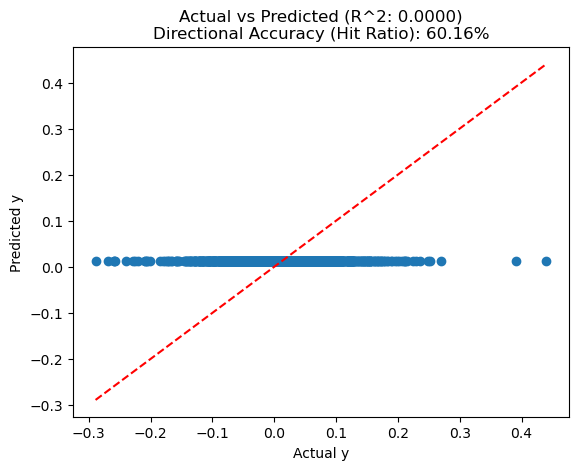

In [ ]:
# as a baseline, predict the mean always

model = DummyRegressor(strategy="mean")
model.fit(X_cache[-1].copy(), y_cache)

y_pred = model.predict(X_cache[-1].copy())
bids_score = bids(model,X_cache[-1].copy(),y_cache)
print(f"BIDS Score: {bids_score}")

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

21 de 21
Index(['Log Returns', 'Quarterly Log Returns', 'Semi-annual Log Returns',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60', 'VMA20',
       'Relative Volume', 'Percentage Intraday Range', 'RSI',
       'Normalized Average True Range', 'Monthly Efficiency Ratio', 'Body Up',
       'Monthly Conviction Ratio', 'Volatility of Volatility',
       'Monthly Overnight Gap Ratio', 'Monthly Skewness', 'Monthly Kurtosis',
       'Quarterly Efficiency Ratio', 'Monthly Close-Location Value',
       'Monthly Intraday Intensity'],
      dtype='str')
                          feature  coefficient  non_zero
0                     Log Returns    -0.001363      True
1           Quarterly Log Returns     0.007836      True
2         Semi-annual Log Returns    -0.006531      True
3          Semi-annual Volatility    -0.003792      True
4                Volatility Ratio    -0.007540      True
5                       MA20/MA60    -0.000604      True
6                           VMA20  

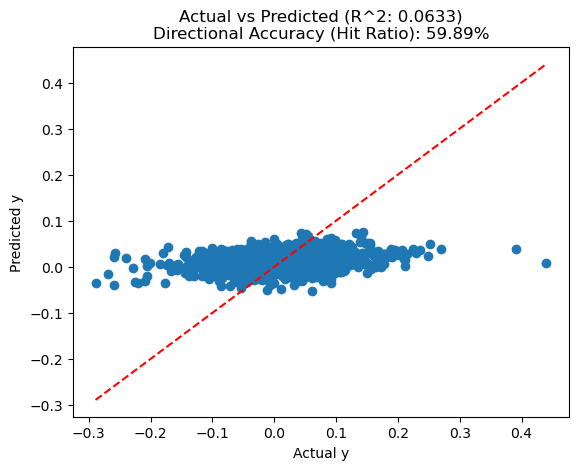

In [ ]:
# retry linear models

X_lin_reg = X_cache[-1].copy() # no hpt needed, so fit on all data at once

model = LinearRegression(n_jobs=-1)
model.fit(X_lin_reg,y_cache)

coefs = model.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = model.predict(X_lin_reg)
bids_score = bids(model,X_cache[-1].copy(),y_cache)
print(f"BIDS Score: {bids_score}")

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

Best Alpha: {'alpha': np.float64(0.001)}
Best Score: 0.04332521931500218
15 de 21
Index(['Quarterly Log Returns', 'Semi-annual Log Returns', 'Volatility Ratio',
       'VMA20', 'Relative Volume', 'Percentage Intraday Range', 'RSI',
       'Normalized Average True Range', 'Monthly Efficiency Ratio', 'Body Up',
       'Volatility of Volatility', 'Monthly Overnight Gap Ratio',
       'Monthly Skewness', 'Quarterly Efficiency Ratio',
       'Monthly Close-Location Value'],
      dtype='str')
                          feature  coefficient  non_zero
0                     Log Returns     0.000000     False
1           Quarterly Log Returns     0.001482      True
2         Semi-annual Log Returns    -0.003299      True
3          Semi-annual Volatility     0.000000     False
4                Volatility Ratio    -0.005034      True
5                       MA20/MA60     0.000000     False
6                           VMA20     0.001117      True
7                 Relative Volume     0.001343     

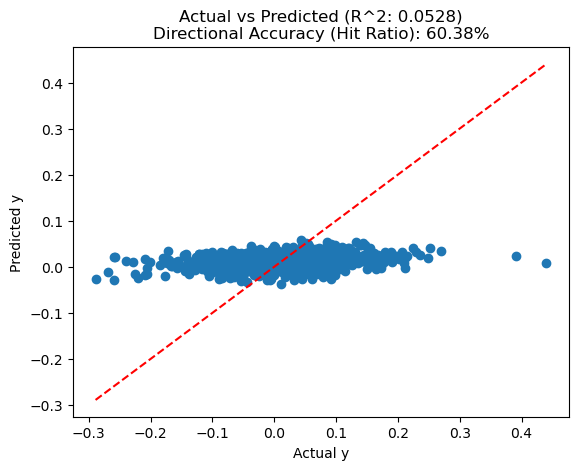

In [30]:
param_grid = {'alpha': np.logspace(-5, -3,3)}
grid = RollingGridSearch(Lasso(max_iter=1000, tol=1e-4, selection="random"), param_grid, min_train_size=12,verbose=0)
grid.fit(X_cache, y_cache)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

Best Alpha: {'alpha': np.float64(1000.0)}
Best Score: 0.063828875821213
21 de 21
Index(['Log Returns', 'Quarterly Log Returns', 'Semi-annual Log Returns',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60', 'VMA20',
       'Relative Volume', 'Percentage Intraday Range', 'RSI',
       'Normalized Average True Range', 'Monthly Efficiency Ratio', 'Body Up',
       'Monthly Conviction Ratio', 'Volatility of Volatility',
       'Monthly Overnight Gap Ratio', 'Monthly Skewness', 'Monthly Kurtosis',
       'Quarterly Efficiency Ratio', 'Monthly Close-Location Value',
       'Monthly Intraday Intensity'],
      dtype='str')
                          feature  coefficient  non_zero
0                     Log Returns    -0.000286      True
1           Quarterly Log Returns     0.000899      True
2         Semi-annual Log Returns    -0.002832      True
3          Semi-annual Volatility     0.000982      True
4                Volatility Ratio    -0.004170      True
5                   

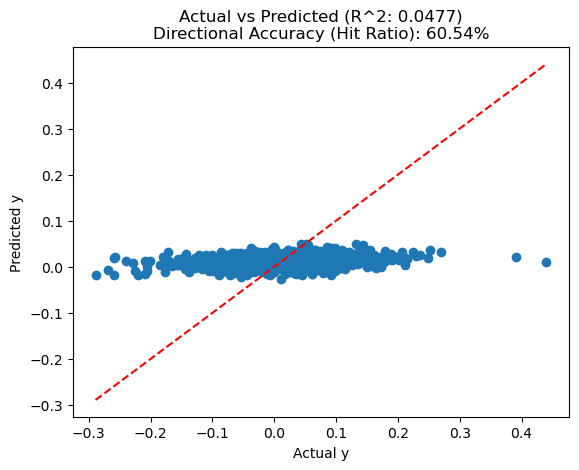

In [29]:
param_grid = {'alpha': np.logspace(0, 3, 4)}
grid = RollingGridSearch(Ridge(max_iter=1000,tol=1e-4,solver="cholesky"), param_grid, min_train_size=12,verbose=0)

grid.fit(X_cache, y_cache)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

Best Alpha: {'alpha': np.float64(0.01), 'l1_ratio': 0.7}
Best Score: 0.0807741948227261
2 de 21
Index(['Volatility Ratio', 'Monthly Overnight Gap Ratio'], dtype='str')
                          feature  coefficient  non_zero
0                     Log Returns    -0.000000     False
1           Quarterly Log Returns    -0.000000     False
2         Semi-annual Log Returns    -0.000000     False
3          Semi-annual Volatility     0.000000     False
4                Volatility Ratio    -0.000893      True
5                       MA20/MA60    -0.000000     False
6                           VMA20     0.000000     False
7                 Relative Volume     0.000000     False
8       Percentage Intraday Range     0.000000     False
9                             RSI    -0.000000     False
10  Normalized Average True Range     0.000000     False
11       Monthly Efficiency Ratio     0.000000     False
12                        Body Up     0.000000     False
13       Monthly Conviction Ratio 

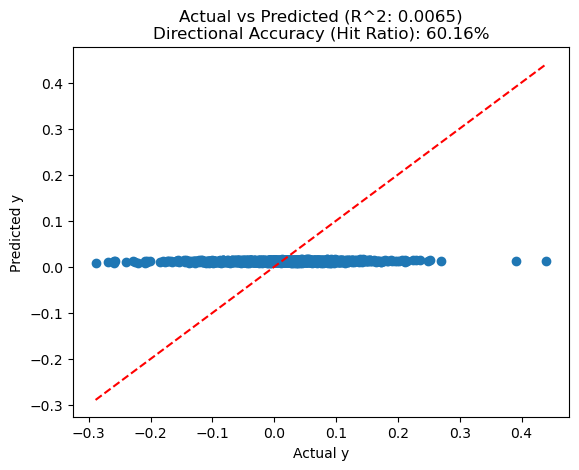

In [ ]:
param_grid = {
    'alpha': np.logspace(-5, 3, 9),
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]
}
grid = RollingGridSearch(ElasticNet(max_iter=1000,tol=1e-4), param_grid, min_train_size=12,verbose=0)

grid.fit(X_cache, y_cache)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

Best Alpha: {'alpha': np.float64(1000.0), 'epsilon': 1.2}
Best Score: 0.044814846002585465
21 de 21
Index(['Log Returns', 'Quarterly Log Returns', 'Semi-annual Log Returns',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60', 'VMA20',
       'Relative Volume', 'Percentage Intraday Range', 'RSI',
       'Normalized Average True Range', 'Monthly Efficiency Ratio', 'Body Up',
       'Monthly Conviction Ratio', 'Volatility of Volatility',
       'Monthly Overnight Gap Ratio', 'Monthly Skewness', 'Monthly Kurtosis',
       'Quarterly Efficiency Ratio', 'Monthly Close-Location Value',
       'Monthly Intraday Intensity'],
      dtype='str')
                          feature  coefficient  non_zero
0                     Log Returns    -0.000191      True
1           Quarterly Log Returns     0.004828      True
2         Semi-annual Log Returns    -0.004895      True
3          Semi-annual Volatility    -0.002012      True
4                Volatility Ratio    -0.003914      True
5

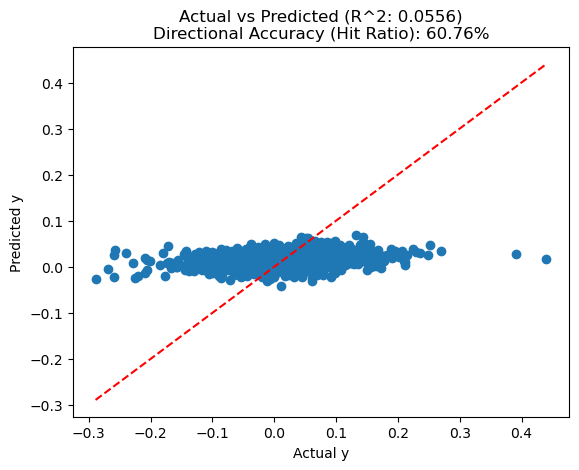

In [33]:
# try one more lin model
# huber regressor is more resistant to outliers

param_grid = {
    'alpha': np.logspace(-1, 3, 4),
    'epsilon': [1,1.2,1.5]
}
grid = RollingGridSearch(HuberRegressor(max_iter=1000,tol=1e-4), param_grid, min_train_size=12,verbose=0)

grid.fit(X_cache, y_cache)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = X.drop(columns="Ticker").columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': X.drop(columns="Ticker").columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# retry random forest with full grid search, see if cached transformations make it quicker
# if it still takes too long will use optuna again

param_grid = {
    'n_estimators': [100,200,500],
    'max_depth': [5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 5, 10,20],
    'min_samples_split': [2,5, 10, 20]
}

grid = RollingGridSearch(RandomForestRegressor(n_jobs=1, random_state=42), param_grid, min_train_size=12,verbose=0)

grid.fit(X_cache, y_cache)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

KeyboardInterrupt: 

In [ ]:
# is too too slow
# will try xgboost now
# then try both again with optuna and see results and compare


param_grid = {
    'n_estimators': [100,200,500,750],
    'learning_rate': [1e-3,1e-2,0.1],
    'max_depth': [3, 5,10],
    'min_child_weight': [1,5,10,20],
    'reg_alpha': [1e-4,1e-3,1e-2,0.1],
    'reg_lambda': [1e-2,0.1,1,5,10],
    'gamma' : [1e-4,1e-2,2,5],
    'subsample': [0.5,1.0],
    'colsample_bytree': [0.5,1.0]
    }

grid = RollingGridSearch(XGBRegressor(n_jobs=1, random_state=42), param_grid, min_train_size=12,verbose=0)

grid.fit(X_cache, y_cache)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

KeyboardInterrupt: 

In [ ]:
# both way too slow
# try now with optuna search, which needs to be rewritten like rolling gridsearch


class RollingOptunaSearch():

    def __init__(self, model_builder, min_train_size=24, n_trials=30, sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.scorer_ = bids
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.verbose = verbose
        self.sampler = sampler or optuna.samplers.TPESampler(multivariate=True, seed=42)
        self.pruner = pruner or optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=5, interval_steps=1)

    def _build_objective(self, Xs, y, lens):


        def objective(trial):

            model_base = self.model_builder(trial)

            scores = []

            for i, (train_len, t) in enumerate(lens):

                X_train, y_train = Xs[t][:train_len], y[:train_len]
                X_test, y_test = Xs[t][train_len:], y[train_len:len(Xs[t])]

                if len(X_test) == 0:
                    continue

                model_step = clone(model_base) if hasattr(model_base, "get_params") else self.model_builder(trial)
                model_step.fit(X_train, y_train)

                score = self.scorer_(model_step, X_test, y_test)
                scores.append(score)

                current_mean = np.mean(scores)

                trial.report(current_mean, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            return np.mean(scores)

        return objective

    def fit(self, X, y):

        lens = [(len(X[t-1]), t) for t in range(max(1, self.min_train_size), len(X))]

        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        study.optimize(self._build_objective(X, y, lens), n_trials=self.n_trials,n_jobs=-1)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)


        X_full = X[-1]

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_))
        self.best_model_.fit(X_full, y)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)    

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-01 19:10:35,380] A new study created in memory with name: no-name-a75057d8-d12f-4181-ad48-5fe749b88254
[I 2026-05-01 19:12:17,695] Trial 2 finished with value: 0.06286893183444907 and parameters: {'n_estimators': 106, 'max_depth': 6, 'max_features': 0.5803840107415617, 'min_samples_leaf': 18, 'min_samples_split': 9}. Best is trial 2 with value: 0.06286893183444907.
[I 2026-05-01 19:12:26,345] Trial 5 finished with value: 0.04734996992979114 and parameters: {'n_estimators': 113, 'max_depth': 12, 'max_features': 0.568632150832461, 'min_samples_leaf': 20, 'min_samples_split': 16}. Best is trial 2 with value: 0.06286893183444907.
[I 2026-05-01 19:13:07,076] Trial 16 finished with value: 0.05687584824238719 and parameters: {'n_estimators': 164, 'max_depth': 10, 'max

Best Params: {'n_estimators': 266, 'max_depth': 5, 'max_features': 0.3205345753345002, 'min_samples_leaf': 9, 'min_samples_split': 10}
Best Score: 0.07951344478802973
21 de 21
Index(['Log Returns', 'Quarterly Log Returns', 'Semi-annual Log Returns',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60', 'VMA20',
       'Relative Volume', 'Percentage Intraday Range', 'RSI',
       'Normalized Average True Range', 'Monthly Efficiency Ratio', 'Body Up',
       'Monthly Conviction Ratio', 'Volatility of Volatility',
       'Monthly Overnight Gap Ratio', 'Monthly Skewness', 'Monthly Kurtosis',
       'Quarterly Efficiency Ratio', 'Monthly Close-Location Value',
       'Monthly Intraday Intensity'],
      dtype='str')
                          feature  importance  non_zero
2         Semi-annual Log Returns    0.130795      True
14       Volatility of Volatility    0.115533      True
4                Volatility Ratio    0.103752      True
15    Monthly Overnight Gap Ratio    0.0834

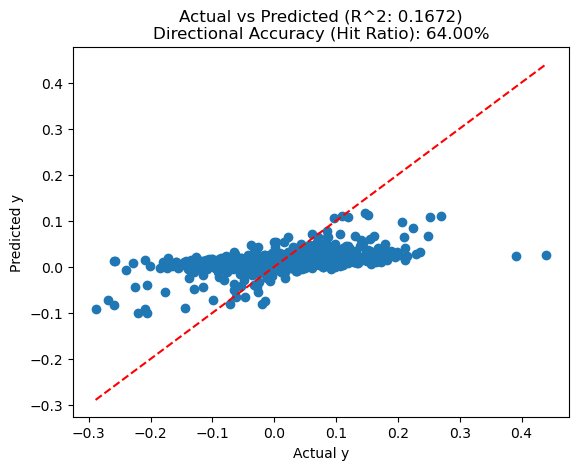

In [37]:
#random forest

def rf_builder(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(rf_builder,min_train_size=12, n_trials=200,pruner=optuna.pruners.PercentilePruner(
    percentile=25.0, 
    n_startup_trials=10, 
    n_warmup_steps=3),verbose=0)

grid.fit(X_cache, y_cache)
random_forest_model = grid.best_model_


print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-01 19:07:17,400] A new study created in memory with name: no-name-fe6d8d42-d289-49d1-acc7-83a1b0acc308
[I 2026-05-01 19:07:48,377] Trial 16 finished with value: 0.05436630152121028 and parameters: {'n_estimators': 224, 'max_depth': 8, 'learning_rate': 0.030574188338206586, 'min_child_weight': 0.3312772135170925, 'gamma': 0.045979667857822655, 'reg_alpha': 6.297311453634437e-05, 'reg_lambda': 0.03222250827745755, 'subsample': 0.8232419558886327, 'colsample_bytree': 0.808324688856157}. Best is trial 16 with value: 0.05436630152121028.
[I 2026-05-01 19:07:54,283] Trial 9 finished with value: 0.06621640800037112 and parameters: {'n_estimators': 276, 'max_depth': 8, 'learning_rate': 0.0418012015659499, 'min_child_weight': 0.9788337618422639, 'gamma': 0.0889156800696

Best Params: {'n_estimators': 1105, 'max_depth': 5, 'learning_rate': 0.011591697418280013, 'min_child_weight': 5.4799204676401985, 'gamma': 0.148635856364364, 'reg_alpha': 0.0006003839455730632, 'reg_lambda': 0.14642700722200158, 'subsample': 0.7201782433282578, 'colsample_bytree': 0.84556858183907}
Best Score: 0.08196202391174409
9 de 21
Index(['Log Returns', 'Quarterly Log Returns', 'Semi-annual Log Returns',
       'Volatility Ratio', 'VMA20', 'RSI', 'Normalized Average True Range',
       'Volatility of Volatility', 'Monthly Overnight Gap Ratio'],
      dtype='str')
                          feature  importance  non_zero
14       Volatility of Volatility    0.118101      True
2         Semi-annual Log Returns    0.113953      True
0                     Log Returns    0.112441      True
15    Monthly Overnight Gap Ratio    0.111532      True
4                Volatility Ratio    0.111190      True
6                           VMA20    0.110859      True
1           Quarterly Log Retur

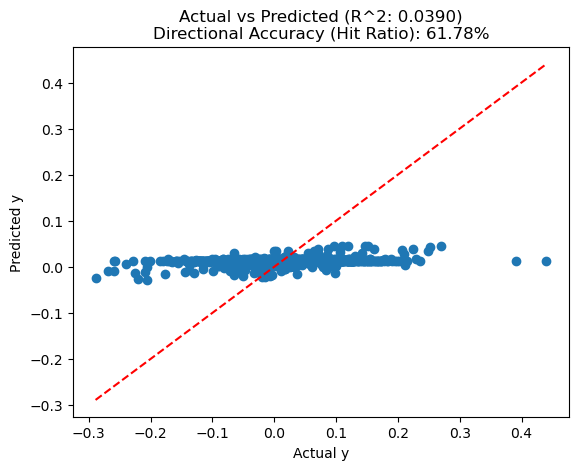

In [36]:
#xgboost

def xg_builder(trial):
    return XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 1200),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        min_child_weight=trial.suggest_float("min_child_weight", 0.1, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 0.15),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-6, 0.5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(xg_builder,min_train_size=12, n_trials=200,pruner = optuna.pruners.PercentilePruner(
    percentile=10.0, 
    n_startup_trials=10, 
    n_warmup_steps=5),verbose=0)

grid.fit(X_cache, y_cache)
xgboost_model = grid.best_model_

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = X.drop(columns="Ticker").columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

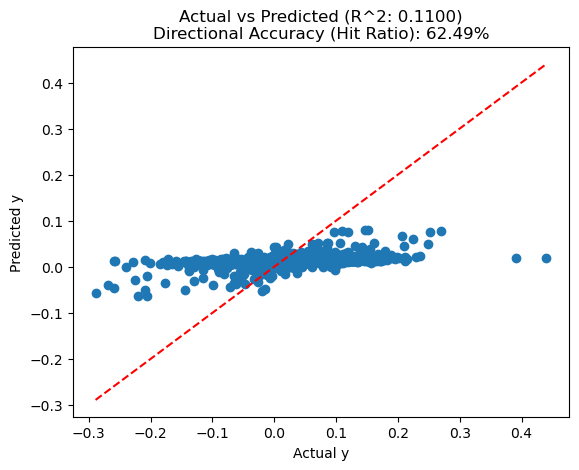

In [38]:
# test out averagin of random forest and xgboost



y_pred = (random_forest_model.predict(X_cache[-1]) + xgboost_model.predict(X_cache[-1])) / 2

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-01 19:18:42,889] A new study created in memory with name: no-name-a9ece54f-c926-4f7c-9725-9c03c5f43cb5
[I 2026-05-01 19:21:10,482] Trial 7 finished with value: 0.011111984368689347 and parameters: {'hidden_layer_sizes': '(64, 32)', 'alpha': 0.11314391527433426, 'learning_rate_init': 0.003924807920762717, 'learning_rate': 'constant', 'batch_size': 1850, 'activation': 'relu'}. Best is trial 7 with value: 0.011111984368689347.
[I 2026-05-01 19:21:42,435] Trial 3 finished with value: -0.012051422396249975 and parameters: {'hidden_layer_sizes': '(32,)', 'alpha': 0.6291977543636814, 'learning_rate_init': 0.0017854392449868411, 'learning_rate': 'adaptive', 'batch_size': 1850, 'activation': 'relu'}. Best is trial 7 with value: 0.011111984368689347.
[I 2026-05-01 19:22:

Best Params: {'hidden_layer_sizes': '(16,)', 'alpha': 2.05614207837052, 'learning_rate_init': 0.0013353906079148008, 'learning_rate': 'adaptive', 'batch_size': 32, 'activation': 'relu'}
Best Score: 0.08787486010985372


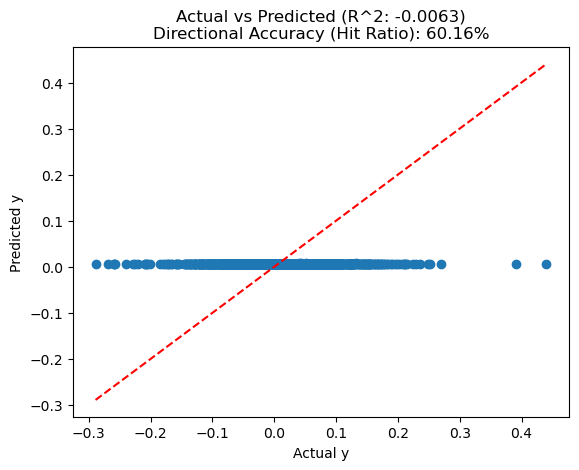

In [ ]:
# simple mlp

def mlp_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["(16,)","(32,)","(64,)", "(128,)",
                                                          "(32, 16)","(64, 32)","(128, 64)",
                                                          "(128, 64, 32)"])

    return MLPRegressor(
        hidden_layer_sizes = literal_eval(hidden),
        alpha=trial.suggest_float("alpha",1e-2, 5.0, log=True),
        learning_rate_init=trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        learning_rate=trial.suggest_categorical("learning_rate", ['constant', 'adaptive']),
        batch_size = trial.suggest_categorical("batch_size", [32,64,128,256,512,len(X_cache[-1])]),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        solver='adam',
        max_iter=1500,
        early_stopping=False,
        random_state=42)

grid = RollingOptunaSearch(mlp_builder,min_train_size=12, n_trials=200, pruner=optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=2,),verbose=0)

grid.fit(X_cache, y_cache)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache[-1])

plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# try out simple mlp but with pytorch for gpu accelaration

class MLP(nn.Module):

    def __init__(self,input_size,hidden_layers,activation,lr,wd,dropout,batch_size):
        super().__init__()
        self.lr = lr
        self.wd = wd
        self.batch_size = batch_size
        layers = []
        in_features = input_size
        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "leaky_relu": nn.LeakyReLU,
            "elu": nn.ELU
        }
        
        use_dropout = dropout > 0

        for i,h in enumerate(hidden_layers):

            lin = nn.Linear(in_features,h)

            if activation == "relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity='relu')
            elif activation == "leaky_relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity='leaky_relu')
            else:
                nn.init.xavier_uniform_(lin.weight)
            nn.init.zeros_(lin.bias)

            layers.append(lin)
            layers.append(activation_map[activation]())

            if use_dropout and i < len(hidden_layers) - 1:
                layers.append(nn.Dropout(dropout))

            in_features = h
        
        lin = nn.Linear(in_features,1)
        nn.init.xavier_uniform_(lin.weight)
        nn.init.zeros_(lin.bias)
        layers.append(lin)

        self.model = nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x).squeeze(-1)

In [18]:
# pytorch version of bids

def bids_torch(y_true, y_pred):

    t_rank = torch.argsort(torch.argsort(y_true)).float()
    p_rank = torch.argsort(torch.argsort(y_pred)).float()
    
    t_rank_c = t_rank - t_rank.mean()
    p_rank_c = p_rank - p_rank.mean()
    
    eps = 1e-8
    rank_ic = (t_rank_c * p_rank_c).mean() / (t_rank_c.std(unbiased=False) * p_rank_c.std(unbiased=False) + eps)
    
    da = (torch.sign(y_true) == torch.sign(y_pred)).float().mean()
    da_centered = 2 * (da - 0.5)
    
    return 0.6 * rank_ic + 0.4 * da_centered

In [19]:
def train_model(model,dataloaders,optimizer,criterion,epochs,verbose=0):
    run_train_loss = []
    run_val_loss = []
    run_bids_score = []
    ema_bids = None
    alpha = 0.9

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,)

    for e in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in dataloaders["train"]:

            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred,batch_y)
            loss.backward()
            optimizer.step()

            n = batch_y.size(0)
            train_loss += loss.item() * n
        
        if "val" in dataloaders:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                preds_list = []
                targets_list = []
                for batch_x, batch_y in dataloaders["val"]:

                    pred = model(batch_x)
                    loss = criterion(pred,batch_y)

                    preds_list.append(pred.detach())
                    targets_list.append(batch_y.detach())

                    n = batch_y.size(0)
                    val_loss += loss.item() * n

                y_pred = torch.cat(preds_list)
                y_true = torch.cat(targets_list)

                current_bids = bids_torch(y_true, y_pred).item()
        
        scheduler.step()
                    
        train_loss /= len(dataloaders["train"].dataset)
        if "val" in dataloaders:
            val_loss /= len(dataloaders["val"].dataset)
            if ema_bids is None:
                ema_bids = current_bids
            else:
                ema_bids = (alpha * ema_bids) + ((1 - alpha) * current_bids)
        
        if verbose:
            print(f"Epoch {e+1}/{epochs}.. ")
            print(f"Train loss: {train_loss:.6f}.. ")
            if "val" in dataloaders:
                print(f"Validation Loss: {val_loss}")
                print(f"BIDS Score: {ema_bids}")
        
        run_train_loss.append(train_loss)
        if "val" in dataloaders:
            run_val_loss.append(val_loss)
            run_bids_score.append(ema_bids)
            
    
    if verbose:
        epochs_range = range(1, e+2)
        plt.plot(epochs_range, run_train_loss, label='Train Loss')
        if "val" in dataloaders:
            plt.plot(epochs_range,run_val_loss, label="Validation Loss")
            plt.plot(epochs_range,run_bids_score, label="BIDS EMA Score")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Loss')
        plt.show()

    
    return max(run_bids_score) if "val" in dataloaders else model
            


In [20]:
# create optuna search for pytorch

class RollingOptunaSearchPyTorch():

    def __init__(self, model_builder,device,min_train_size=24, n_trials=30, sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.device = device
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.verbose = verbose
        self.sampler = sampler or optuna.samplers.TPESampler(multivariate=True, seed=42)
        self.pruner = pruner or optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=5, interval_steps=1)

    def _build_objective(self, Xs, y, lens):


        def objective(trial):

            scores = []

            for i, (train_len,t) in enumerate(lens):

                model_step = self.model_builder(trial).to(self.device)

                X_train, y_train = Xs[t][:train_len], y[:train_len]
                X_val, y_val = Xs[t][train_len:], y[train_len:len(Xs[t])]

                if len(X_val) == 0:
                    continue

                train_dataset = TensorDataset(X_train,y_train)
                train_dataloader = DataLoader(train_dataset,batch_size=model_step.batch_size,shuffle=False)
    
                val_dataset = TensorDataset(X_val,y_val)
                val_dataloader = DataLoader(val_dataset,batch_size=model_step.batch_size,shuffle=False)
                dataloaders = {"train" : train_dataloader, "val" : val_dataloader}
                score = train_model(model_step,dataloaders,optim.AdamW(model_step.parameters(),lr=model_step.lr,weight_decay=model_step.wd),nn.MSELoss(),130,0)

                scores.append(score)

                mean = np.mean(scores)

                trial.report(mean, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            return mean

        return objective

    def fit(self, X, y):

        lens = [(len(X[t-1]), t) for t in range(max(1, self.min_train_size), len(X))]

        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        study.optimize(self._build_objective(X, y, lens), n_trials=self.n_trials)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_)).to(self.device)
        X_full = X[-1]
        train_dataset = TensorDataset(X_full,y)
        train_dataloader = DataLoader(train_dataset,batch_size=self.best_model_.batch_size,shuffle=False)
        dataloaders = {"train": train_dataloader}
        self.best_model_ = train_model(self.best_model_,dataloaders,optim.AdamW(self.best_model_.parameters(),lr=self.best_model_.lr,weight_decay=self.best_model_.wd),nn.MSELoss(),200,1,)

        return self

    def predict(self, X):
        self.best_model_.eval()
        with torch.no_grad():
            return self.best_model_(X).cpu().numpy()   

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-01 11:19:41,549] A new study created in memory with name: no-name-497c36d3-8098-46e0-b324-09502cb565f9
[I 2026-05-01 11:20:35,599] Trial 0 finished with value: 0.06930104981380432 and parameters: {'hidden_layer_sizes': '[32]', 'activation': 'tanh', 'lr': 0.00010994335574766199, 'wd': 0.07579479953348005, 'dropout': 0.45, 'batch_size': 512}. Best is trial 0 with value: 0.06930104981380432.
[I 2026-05-01 11:22:22,004] Trial 1 finished with value: 0.12024815329080149 and parameters: {'hidden_layer_sizes': '[128, 64]', 'activation': 'tanh', 'lr': 0.0001238513729886094, 'wd': 0.0026926469100861782, 'dropout': 0.05, 'batch_size': 128}. Best is trial 1 with value: 0.12024815329080149.
[I 2026-05-01 11:25:18,249] Trial 2 finished with value: 0.13669956890337853 and par

Epoch 1/200.. 
Train loss: 0.335834.. 
Epoch 2/200.. 
Train loss: 0.017988.. 
Epoch 3/200.. 
Train loss: 0.010138.. 
Epoch 4/200.. 
Train loss: 0.008044.. 
Epoch 5/200.. 
Train loss: 0.006270.. 
Epoch 6/200.. 
Train loss: 0.006016.. 
Epoch 7/200.. 
Train loss: 0.005419.. 
Epoch 8/200.. 
Train loss: 0.005114.. 
Epoch 9/200.. 
Train loss: 0.005102.. 
Epoch 10/200.. 
Train loss: 0.004963.. 
Epoch 11/200.. 
Train loss: 0.005035.. 
Epoch 12/200.. 
Train loss: 0.005064.. 
Epoch 13/200.. 
Train loss: 0.004819.. 
Epoch 14/200.. 
Train loss: 0.004929.. 
Epoch 15/200.. 
Train loss: 0.004875.. 
Epoch 16/200.. 
Train loss: 0.004719.. 
Epoch 17/200.. 
Train loss: 0.004836.. 
Epoch 18/200.. 
Train loss: 0.004715.. 
Epoch 19/200.. 
Train loss: 0.004676.. 
Epoch 20/200.. 
Train loss: 0.004845.. 
Epoch 21/200.. 
Train loss: 0.004653.. 
Epoch 22/200.. 
Train loss: 0.004741.. 
Epoch 23/200.. 
Train loss: 0.004618.. 
Epoch 24/200.. 
Train loss: 0.004642.. 
Epoch 25/200.. 
Train loss: 0.004632.. 
Epoch 26/

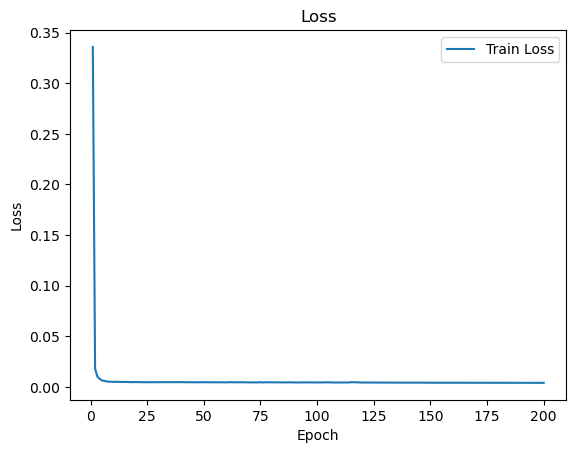

Best Params: {'hidden_layer_sizes': '[128, 64, 32]', 'activation': 'relu', 'lr': 0.006943972347407891, 'wd': 0.0012012466793333912, 'dropout': 0.4, 'batch_size': 32}
Best Score: 0.26402344307599784


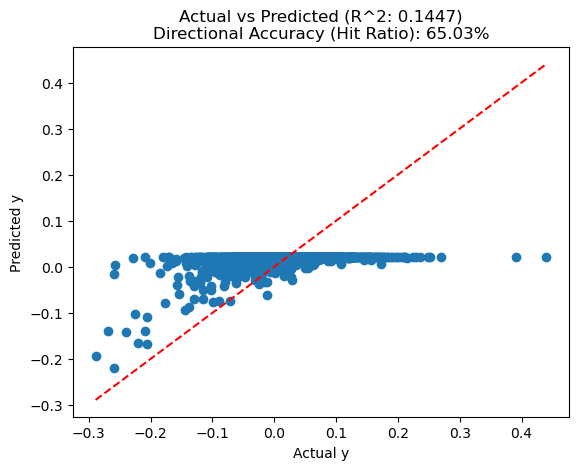

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_cache_t = [torch.tensor(x, dtype=torch.float32, device=device) for x in X_cache]
y_cache_t = torch.tensor(y_cache, dtype=torch.float32, device=device)
input_features = X_cache_t[0].shape[1]

def mlp_pytorch_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[16]", "[32]","[64]", "[128]",
                                                              "[32, 16]","[64, 32]","[128, 64]",
                                                              "[128, 64, 32]"])
    return MLP(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh','leaky_relu','elu']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.4,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(mlp_pytorch_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()


/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-01 11:19:41,549] A new study created in memory with name: no-name-497c36d3-8098-46e0-b324-09502cb565f9
[I 2026-05-01 11:20:35,599] Trial 0 finished with value: 0.06930104981380432 and parameters: {'hidden_layer_sizes': '[32]', 'activation': 'tanh', 'lr': 0.00010994335574766199, 'wd': 0.07579479953348005, 'dropout': 0.45, 'batch_size': 512}. Best is trial 0 with value: 0.06930104981380432.
[I 2026-05-01 11:22:22,004] Trial 1 finished with value: 0.12024815329080149 and parameters: {'hidden_layer_sizes': '[128, 64]', 'activation': 'tanh', 'lr': 0.0001238513729886094, 'wd': 0.0026926469100861782, 'dropout': 0.05, 'batch_size': 128}. Best is trial 1 with value: 0.12024815329080149.
[I 2026-05-01 11:25:18,249] Trial 2 finished with value: 0.13669956890337853 and par

Epoch 1/200.. 
Train loss: 0.335834.. 
Epoch 2/200.. 
Train loss: 0.017988.. 
Epoch 3/200.. 
Train loss: 0.010138.. 
Epoch 4/200.. 
Train loss: 0.008044.. 
Epoch 5/200.. 
Train loss: 0.006270.. 
Epoch 6/200.. 
Train loss: 0.006016.. 
Epoch 7/200.. 
Train loss: 0.005419.. 
Epoch 8/200.. 
Train loss: 0.005114.. 
Epoch 9/200.. 
Train loss: 0.005102.. 
Epoch 10/200.. 
Train loss: 0.004963.. 
Epoch 11/200.. 
Train loss: 0.005035.. 
Epoch 12/200.. 
Train loss: 0.005064.. 
Epoch 13/200.. 
Train loss: 0.004819.. 
Epoch 14/200.. 
Train loss: 0.004929.. 
Epoch 15/200.. 
Train loss: 0.004875.. 
Epoch 16/200.. 
Train loss: 0.004719.. 
Epoch 17/200.. 
Train loss: 0.004836.. 
Epoch 18/200.. 
Train loss: 0.004715.. 
Epoch 19/200.. 
Train loss: 0.004676.. 
Epoch 20/200.. 
Train loss: 0.004845.. 
Epoch 21/200.. 
Train loss: 0.004653.. 
Epoch 22/200.. 
Train loss: 0.004741.. 
Epoch 23/200.. 
Train loss: 0.004618.. 
Epoch 24/200.. 
Train loss: 0.004642.. 
Epoch 25/200.. 
Train loss: 0.004632.. 
Epoch 26/

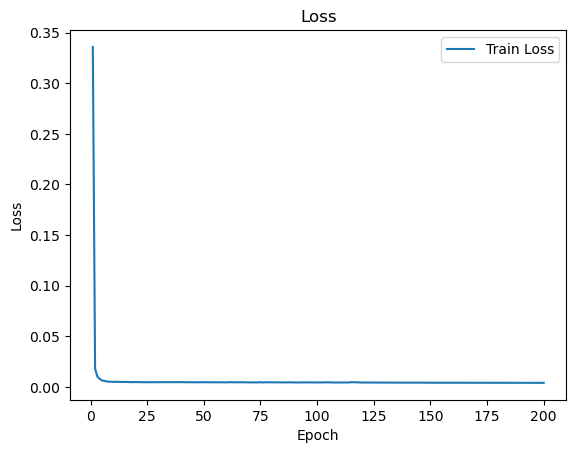

Best Params: {'hidden_layer_sizes': '[128, 64, 32]', 'activation': 'relu', 'lr': 0.006943972347407891, 'wd': 0.0012012466793333912, 'dropout': 0.4, 'batch_size': 32}
Best Score: 0.26402344307599784


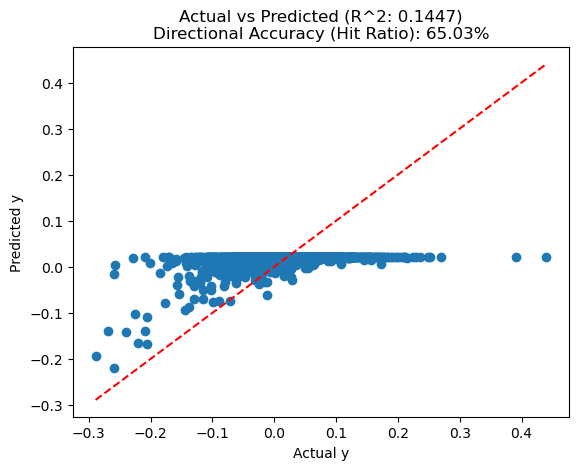

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_cache_t = [torch.tensor(x, dtype=torch.float32, device=device) for x in X_cache]
y_cache_t = torch.tensor(y_cache, dtype=torch.float32, device=device)
input_features = X_cache_t[0].shape[1]

def mlp_pytorch_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[32]","[64]", "[128]",
                                                              "[32, 16]","[64, 32]","[128, 64]",
                                                              "[128, 64, 32]", "[64,64,64]"])
    return MLP(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-5, 1e-1, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.5,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(mlp_pytorch_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()


In [ ]:
# now move onto final two models, CNN, RNN
# CNN first

def CNN(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)


In [ ]:
def cnn_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[256]", "[64, 32]",
                                                              "[128, 64]","[256, 128]",
                                                              "[128, 64, 32]", "[256, 128, 64]",
                                                              "[256, 128, 32]", "[256, 128, 64, 32]"])
    return CNN(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(cnn_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# finally, RNN

def LSTM(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)


In [ ]:
def lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[256]", "[64, 32]",
                                                              "[128, 64]","[256, 128]",
                                                              "[128, 64, 32]", "[256, 128, 64]",
                                                              "[256, 128, 32]", "[256, 128, 64, 32]"])
    return LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(lstm_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
#try a mix of cnn and lstm

def CNN_LSTM(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)

In [ ]:
def cnn_lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[256]", "[64, 32]",
                                                              "[128, 64]","[256, 128]",
                                                              "[128, 64, 32]", "[256, 128, 64]",
                                                              "[256, 128, 32]", "[256, 128, 64, 32]"])
    return CNN_LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(cnn_lstm_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# transformer

Forget standard configs. Think:

Layers: 1–2
Heads: 1–2
Embedding dim: 16–32
FFN dim: 32–64

Anything bigger = overfitting machine.

A rough mental target:

<100k parameters total